# Running Simulator

In [54]:
import numpy as np
import pandas as pd
from simulator import simulate

In [55]:
# Run one replicate with specific parameters
rng = np.random.default_rng(42)
infected, rewires, degrees = simulate(beta=0.3, gamma=0.15, rho=0.7, rng=rng)

In [56]:
print("Final infected:", infected[-1])
print("Length of infected series:", len(infected))
print("Length of rewires series:", len(rewires))
print("Length of degrees vector:", len(degrees))

Final infected: 0.0
Length of infected series: 201
Length of rewires series: 201
Length of degrees vector: 31


In [57]:
infected

array([0.025, 0.06 , 0.075, 0.095, 0.115, 0.15 , 0.17 , 0.225, 0.26 ,
       0.28 , 0.295, 0.3  , 0.305, 0.27 , 0.28 , 0.275, 0.245, 0.205,
       0.175, 0.145, 0.12 , 0.115, 0.095, 0.08 , 0.075, 0.065, 0.06 ,
       0.055, 0.045, 0.035, 0.025, 0.025, 0.02 , 0.02 , 0.02 , 0.02 ,
       0.015, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   ,

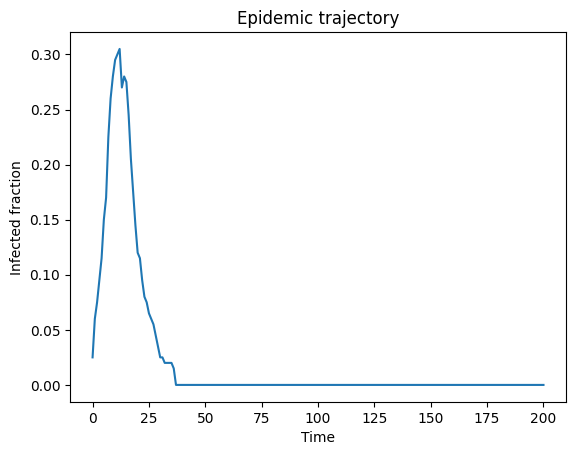

In [58]:
import matplotlib.pyplot as plt

plt.plot(infected)
plt.xlabel("Time")
plt.ylabel("Infected fraction")
plt.title("Epidemic trajectory")
plt.show()

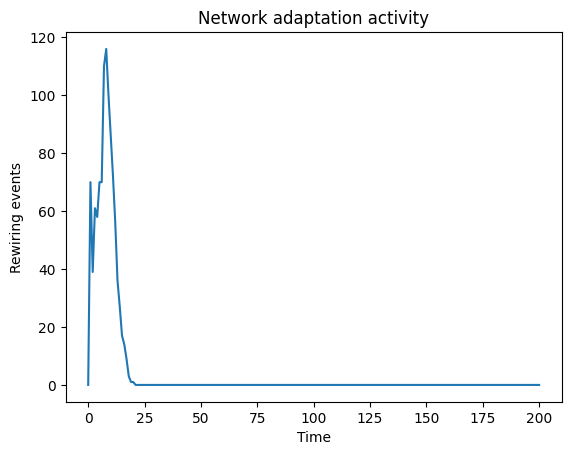

In [59]:
plt.plot(rewires)
plt.xlabel("Time")
plt.ylabel("Rewiring events")
plt.title("Network adaptation activity")
plt.show()

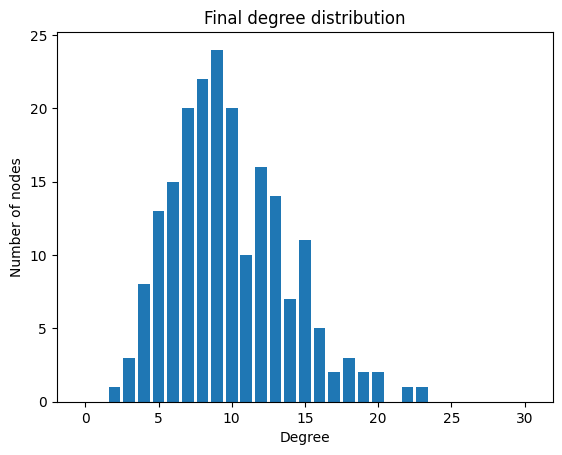

In [60]:
plt.bar(range(31), degrees)
plt.xlabel("Degree")
plt.ylabel("Number of nodes")
plt.title("Final degree distribution")
plt.show()

# Summary Statistics

In [61]:
def compute_summaries(infected_fraction, rewire_counts, degree_histogram):
    """
    Computes summary statistics from one simulation replicate.
    
    Parameters
    ----------
    infected_fraction : array of shape (201,)
    rewire_counts     : array of shape (201,)
    degree_histogram  : array of shape (31,)  — counts per degree 0..30
    
    Returns
    -------
    summaries : 1D numpy array of length 7
    """
    degrees = np.arange(31)
    weights = degree_histogram / degree_histogram.sum()  # normalise to probabilities
    
    mean_degree = np.sum(degrees * weights)
    var_degree  = np.sum((degrees - mean_degree)**2 * weights)
    
    summaries = np.array([
        np.max(infected_fraction),           # 1. peak
        np.argmax(infected_fraction),        # 2. time to peak
        np.sum(infected_fraction),           # 3. epidemic size (proxy)
        np.sum(rewire_counts),               # 4. total rewiring
        np.max(rewire_counts),               # 5. max rewiring
        mean_degree,                         # 6. mean degree
        var_degree,                          # 7. degree variance
    ], dtype=float)
    
    return summaries

In [62]:
# Test it works on the simulation you already ran
s = compute_summaries(infected, rewires, degrees)
labels = ['peak', 'time_to_peak', 'epidemic_size', 
          'total_rewiring', 'max_rewiring', 'mean_degree', 'var_degree']
for l, v in zip(labels, s):
    print(f"{l:20s}: {v:.4f}")

peak                : 0.3050
time_to_peak        : 12.0000
epidemic_size       : 4.8400
total_rewiring      : 1016.0000
max_rewiring        : 116.0000
mean_degree         : 9.8400
var_degree          : 15.4144


### Sensitivity analysis

In [63]:
rng2 = np.random.default_rng(0)
N = 200  # number of random simulations

params = []
all_summaries = []

for i in range(N):
    beta  = rng2.uniform(0.05, 0.50)
    gamma = rng2.uniform(0.02, 0.20)
    rho   = rng2.uniform(0.00, 0.80)
    
    inf, rew, deg = simulate(beta=beta, gamma=gamma, rho=rho, rng=rng2)
    s = compute_summaries(inf, rew, deg)
    
    params.append([beta, gamma, rho])
    all_summaries.append(s)

params = np.array(params)
all_summaries = np.array(all_summaries)

### Correlation table

In [64]:
param_names   = ['beta', 'gamma', 'rho']
summary_names = ['peak', 'time_to_peak', 'epidemic_size',
                 'total_rewiring', 'max_rewiring', 'mean_degree', 'var_degree']

corr_matrix = np.zeros((len(summary_names), len(param_names)))

for i in range(len(summary_names)):
    for j in range(len(param_names)):
        corr_matrix[i, j] = np.corrcoef(all_summaries[:, i], params[:, j])[0, 1]

df = pd.DataFrame(corr_matrix, index=summary_names, columns=param_names)
print(df.round(3))

                 beta  gamma    rho
peak            0.655 -0.535 -0.334
time_to_peak   -0.381 -0.214  0.009
epidemic_size   0.203 -0.776 -0.134
total_rewiring  0.027 -0.218  0.559
max_rewiring    0.446 -0.263  0.650
mean_degree     0.067  0.023 -0.045
var_degree     -0.305  0.020  0.678


### Heatmap

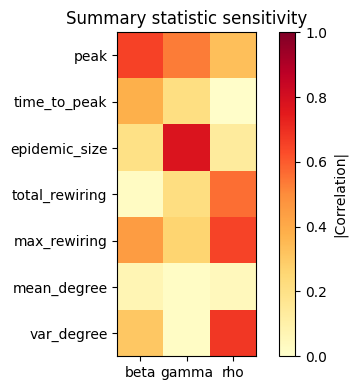

In [65]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(np.abs(corr_matrix), vmin=0, vmax=1, cmap='YlOrRd')
ax.set_xticks(range(3));  ax.set_xticklabels(param_names)
ax.set_yticks(range(7));  ax.set_yticklabels(summary_names)
plt.colorbar(im, ax=ax, label='|Correlation|')
ax.set_title("Summary statistic sensitivity")
plt.tight_layout()
plt.show()